<a href="https://colab.research.google.com/github/elgabo82/Air_Quality_TAA-UNIR-A1/blob/main/Actividad_1_Gabriel_Morej%C3%B3n_L%C3%B3pez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [ ]:
## cargar el dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Como dato a tener en cuenta en el tratamiento de los datos, en el archivo se
# emplea como separador de las columnas ';' y para los decimales ','
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
# Se busca eliminar columnas vacias de relleno, se puede notar en la imagen más abajo
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# contar filas vacías
vacias = df.isna().all(axis=1).sum()
# eliminar filas completamente vacias
df = df.dropna(how='all').reset_index(drop=True)



df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Como se muestra en esta captura, hay columnas de relleno
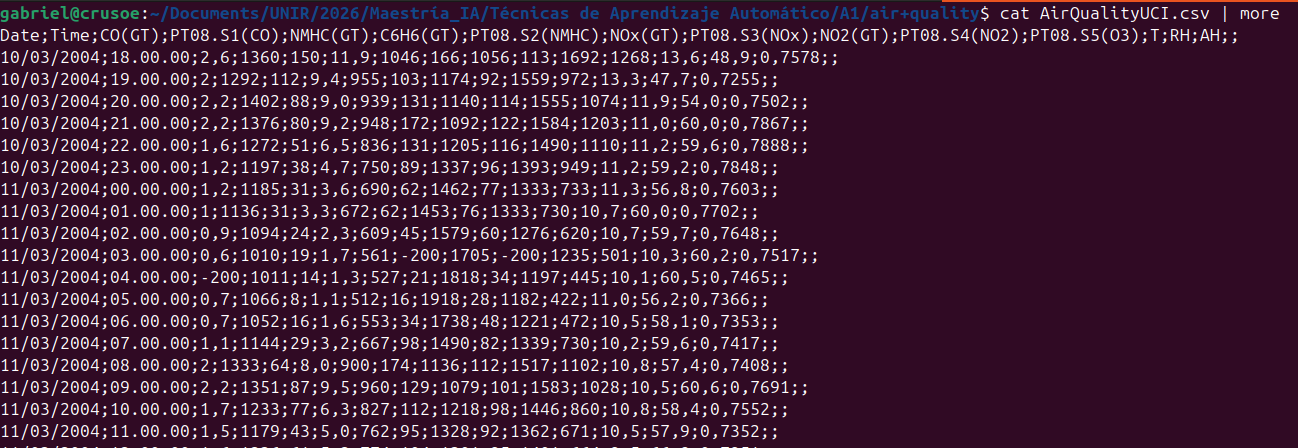

In [41]:
df.info()
# Se muestran las columnas y sus tipos de datos, o por lo menos los tipos que
# se identifican en Python (float, object, entre otros)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [42]:
## ¿cuántas instancias tiene el dataset?
n_instancias = df.shape[0]
print(f"Número de instancias: {n_instancias}")

# Para eliminar las filas vacías del dataset
#df = df.dropna(how='all')

print(f"Cantidad de filas que solo tienen puntos y comas: {vacias}")

Número de instancias: 9357
Cantidad de filas que solo tienen puntos y comas: 114


El archivo contiene filas vacías, cuyo número total se indicó previamente
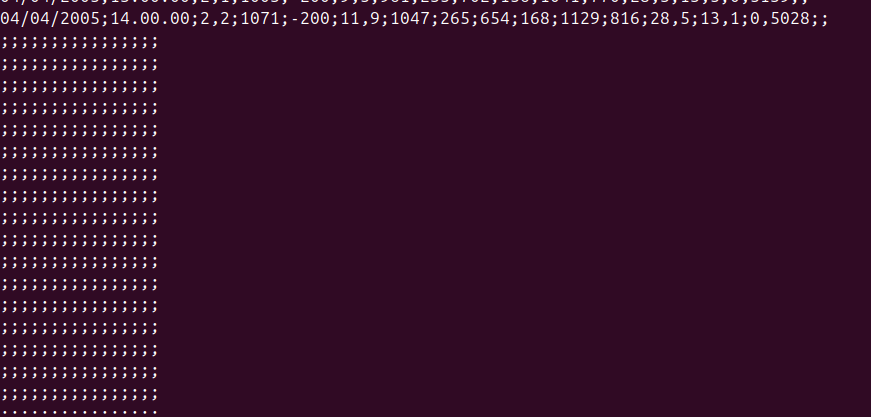

El conjunto de datos (dataset) contiene **9357** tantas instancias, conforme el conteo realizado

In [43]:
## ¿cuál es el tipo de datos de cada una de las columnas?
df.dtypes

,0
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


El conjunto de datos tiene dos columnas `Date` y `Time` son de tipo *object* (cadenas de texto) y las demás columnas son de tipo `float64`; (`CO(GT)`, `PT08.S1(CO)`, `NMHC(GT)`, `C6H6(GT)`, `PT08.S2(NMHC)`, `NOx(GT)`, `PT08.S3(NOx)`, `NO2(GT)`, `PT08.S4(NO2)`, `PT08.S5(O3)`, `T`, `RH`, `AH`), que se estima contienen la información de muestras de los sensores.

In [44]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
categoricas = df.select_dtypes(include='object').columns.tolist()
continuas = df.select_dtypes(include='number').columns.tolist()
print("No numéricas / categóricas:", categoricas, "->", len(categoricas))
print("Continuas:", len(continuas))

No numéricas / categóricas: ['Date', 'Time'] -> 2
Continuas: 13


El dataset contiene **2 columnas no numéricas** y **13 continuas** con los tipos de datos indicados previamente.

In [45]:
## ¿existen valores nulos en el dataset?
print("Nulos (NaN) detectados por pandas:", df.isna().sum().sum())

# El repositorio UCI documenta que los valores perdidos están codificados con -200
# en vez de con NaN, por lo que pandas no los detecta como nulos si no se tratan antes.
num_cols = [c for c in df.columns if c not in ('Date', 'Time')]
print("\nValores codificados como -200 por columna:")
print((df[num_cols] == -200).sum())

Nulos (NaN) detectados por pandas: 0

Valores codificados como -200 por columna:
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


El uso de la función `isna()` de **pandas** no detecta valores nulos, pero como se indicó anteriormente; el conjunto de datos **sí tiene valores nulos o faltantes**, de la revisión en la información del dataset se indica que esos valores están codificados con **-200** y esto hace que **pandas** no los detecte, dichos valores deben tratarse adecuadamente por sejemplo con **NaN** como se muestra en la imagen.
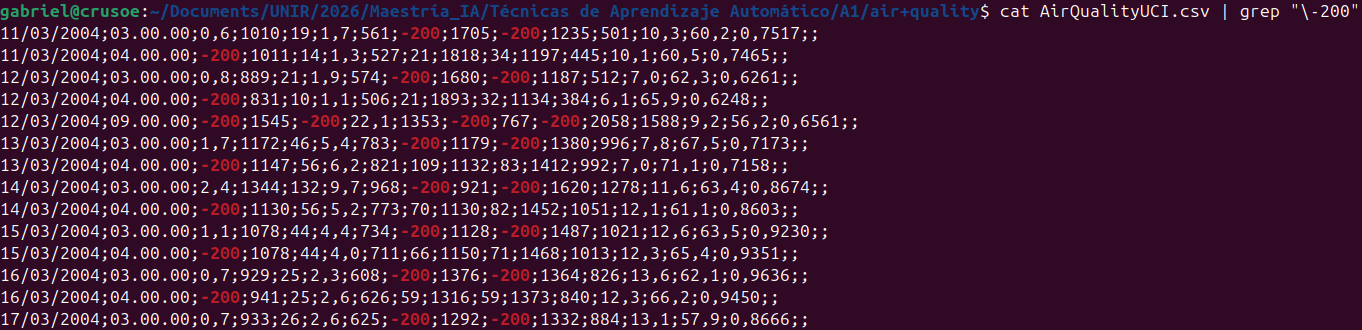


In [46]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
objetivo = 'CO(GT)'
print(f"Variable respuesta seleccionada: {objetivo}")
print(f"Tipo de dato: {df[objetivo].dtype} -> variable continua/cuantitativa")

Variable respuesta seleccionada: CO(GT)
Tipo de dato: float64 -> variable continua/cuantitativa


Se escoge **`CO(GT)`** (concentración de monóxido de carbono medida por el analizador de referencia, en mg/m³) como variable respuesta; cabe mencionar que es una **variable continua/cuantitativa** (tipo `float64`), por lo que el problema es de regresión y no de clasificación, básicamente porque según lo indicado en la referencia del dataset y el [artículo base de la investigación](https://www.sciencedirect.com/science/article/abs/pii/S0925400507007691?via%3Dihub), el sensor estuvo en un lugar de alta contaminación en una ciudad italiana y se puede considerar una referencia válida del análisis de concentración de **CO**.

            CO(GT)      NOx(GT)      NO2(GT)
count  7674.000000  7718.000000  7715.000000
mean      2.152750   246.896735   113.091251
std       1.453252   212.979168    48.370108
min       0.100000     2.000000     2.000000
25%       1.100000    98.000000    78.000000
50%       1.800000   180.000000   109.000000
75%       2.900000   326.000000   142.000000
max      11.900000  1479.000000   340.000000

Asimetría (skewness):
CO(GT)     1.369753
NOx(GT)    1.715781
NO2(GT)    0.621714
dtype: float64


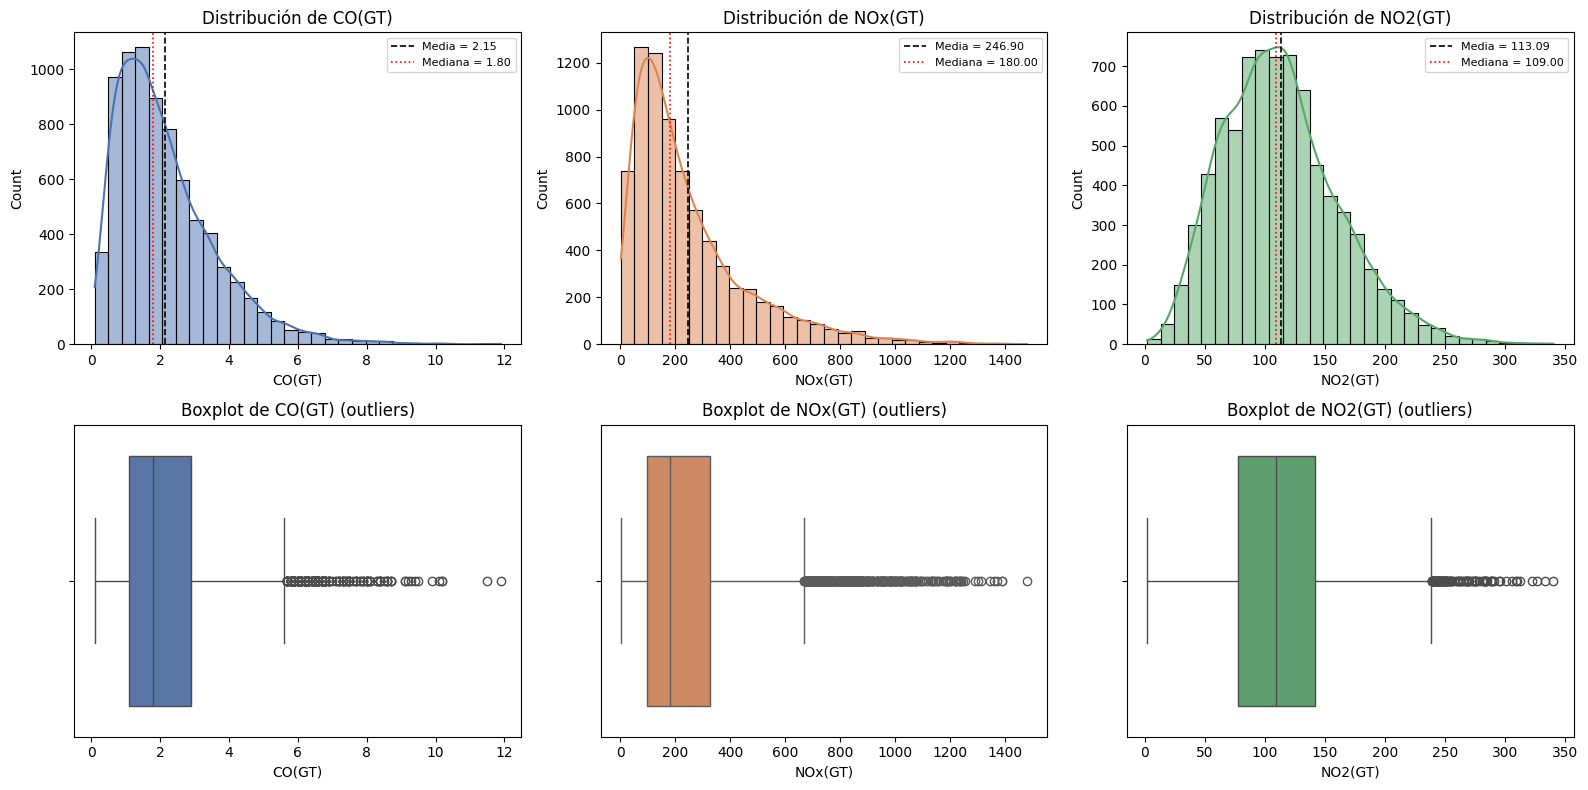

In [47]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?
df_clean = df.copy()
df_clean[num_cols] = df_clean[num_cols].replace(-200, np.nan)

stats = df_clean[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].describe()
skew = df_clean[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].skew()
print(stats)
print("\nAsimetría (skewness):")
print(skew)

variables = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col_i, (var, color) in enumerate(zip(variables, colores)):
    datos = df_clean[var].dropna()
    media = datos.mean()
    mediana = datos.median()

    # Fila 1: histograma + curva de densidad (forma de la distribución)
    ax_hist = axes[0, col_i]
    sns.histplot(datos, kde=True, ax=ax_hist, color=color, bins=30)
    ax_hist.axvline(media, color='black', linestyle='--', linewidth=1.2, label=f'Media = {media:.2f}')
    ax_hist.axvline(mediana, color='red', linestyle=':', linewidth=1.2, label=f'Mediana = {mediana:.2f}')
    ax_hist.set_title(f'Distribución de {var}')
    ax_hist.set_xlabel(var)
    ax_hist.legend(fontsize=8)

    # Fila 2: boxplot (para ver los valores atípicos/anómalos)
    ax_box = axes[1, col_i]
    sns.boxplot(x=datos, ax=ax_box, color=color)
    ax_box.set_xlabel(var)
    ax_box.set_title(f'Boxplot de {var} (outliers)')

plt.tight_layout()
plt.show()

Conforme lo revisado y el análisis de otros [artículos](https://www.redalyc.org/journal/176/17664443009/html/), las tres variables presentan **distribución asimétrica hacia la derecha** (asimetría positiva: CO≈1.37, NOx≈1.72, NO2≈0.62), típica de concentraciones de contaminantes; mismas que están delimitadas al límite inferior por 0 y en algunos casos presentan picos elevados de contaminación. `NOx(GT)` es la más asimétrica: su mediana (180 µg/m³) está muy por debajo de su máximo (1479 µg/m³). `CO(GT)` tiene media 2.15 mg/m³ y mediana 1.8 mg/m³; `NO2(GT)` es la menos asimétrica de las tres, con media (113.1) y mediana (109) más próximas entre sí.

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

Dese mi punto de vista **Sí**, tal como se evidencia en los gráficos previos: las tres muestran una distribución **no normal, con cola derecha larga** (sesgo positivo), coherente con episodios puntuales de alta contaminación; y para este conjunto de datos es evidente que todas tienen **datos faltantes** codificados como -200 (18.0% en CO(GT), 17.5% en NOx(GT) y NO2(GT), posiblemente por **_caídas del dispositivo_**, lo que indica fallos adicionales del analizador de referencia en estos contaminantes concretos). Es evidente también que hay **datos anómalos/atípicos**: antes de limpiar, el valor -200 debe tratarse como ausente y no como una medición real; una vez limpiado el conjunto de datos, persisten valores altos legítimos (p. ej. NOx(GT) hasta 1479 µg/m³, ~8 veces la mediana) que actúan como puntos de alto *leverage* para un modelo lineal.

In [48]:
## ¿cómo son las correlaciones entre las variables del dataset?
corr = df_clean[num_cols].corr()
corr.round(2)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.00,0.88,0.89,0.93,0.92,0.80,-0.70,0.68,0.63,0.85,0.02,0.05,0.05
PT08.S1(CO),0.88,1.00,0.79,0.88,0.89,0.71,-0.77,0.64,0.68,0.90,0.05,0.11,0.14
NMHC(GT),0.89,0.79,1.00,0.90,0.88,0.81,-0.77,0.73,0.85,0.77,0.39,-0.19,0.27
C6H6(GT),0.93,0.88,0.90,1.00,0.98,0.72,-0.74,0.61,0.77,0.87,0.20,-0.06,0.17
PT08.S2(NMHC),0.92,0.89,0.88,0.98,1.00,0.70,-0.80,0.65,0.78,0.88,0.24,-0.09,0.19
NOx(GT),0.80,0.71,0.81,0.72,0.70,1.00,-0.66,0.76,0.23,0.79,-0.27,0.22,-0.15
PT08.S3(NOx),-0.70,-0.77,-0.77,-0.74,-0.80,-0.66,1.00,-0.65,-0.54,-0.80,-0.15,-0.06,-0.23
NO2(GT),0.68,0.64,0.73,0.61,0.65,0.76,-0.65,1.00,0.16,0.71,-0.19,-0.09,-0.34
PT08.S4(NO2),0.63,0.68,0.85,0.77,0.78,0.23,-0.54,0.16,1.00,0.59,0.56,-0.03,0.63
PT08.S5(O3),0.85,0.90,0.77,0.87,0.88,0.79,-0.80,0.71,0.59,1.00,-0.03,0.12,0.07


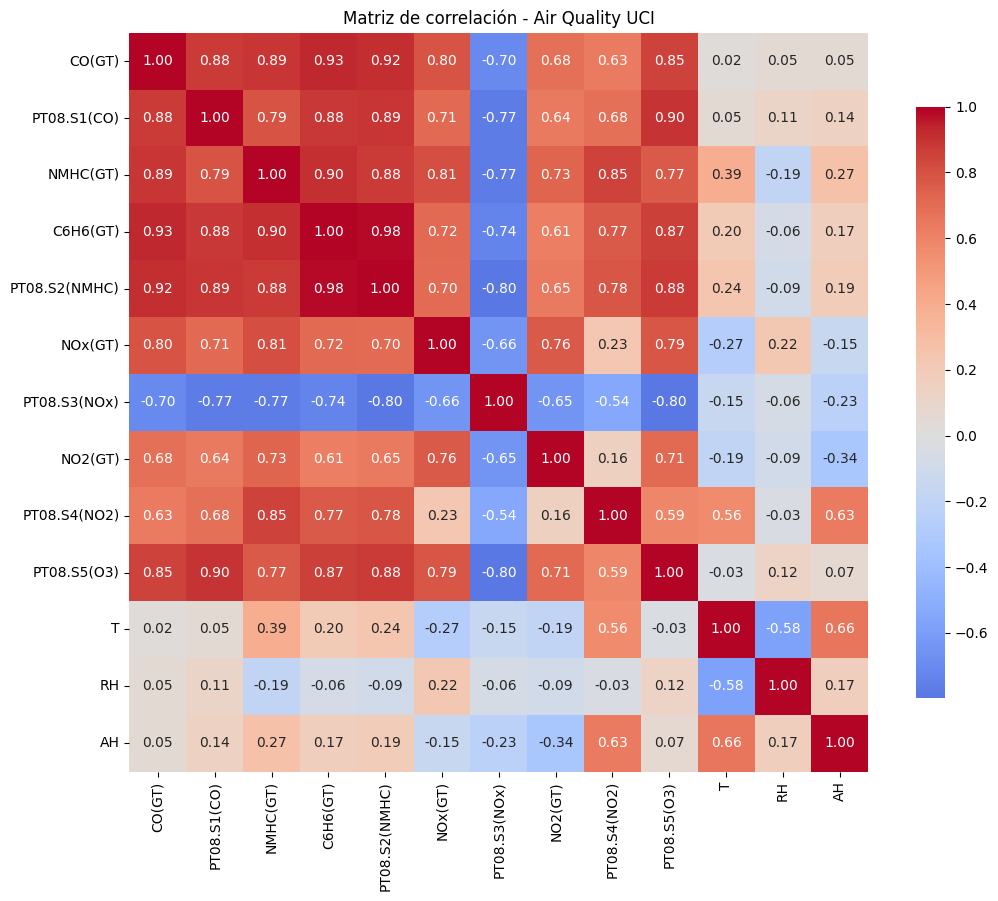

In [49]:
#import matplotlib.pyplot as plt
#import seaborn as sns

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación - Air Quality UCI")
plt.tight_layout()
plt.show()

De la matriz d correlación, se obtiene que los contaminantes y sus sensores asociados están **fuertemente correlacionados de forma positiva** entre sí (r entre 0.6 y 0.98), ya que comparten un origen común: el tráfico y la combustión; es importante también, tener en cuenta el caso de `PT08.S3(NOx)`, que se correlaciona **negativamente** con casi todo el resto (p. ej. r=-0.70 con CO(GT), r=-0.80 con PT08.S5(O3)); esto no es una relación física inversa entre contaminantes, sino una característica del propio sensor, puesto que su conductividad eléctrica disminuye cuando aumenta la concentración de NOx, con base en lo expuesto, las variables meteorológicas (`T`, `RH`, `AH`) muestran correlaciones débiles con los contaminantes (|r| generalmente <0.3), aunque están relacionadas entre sí de forma esperable (T y AH: r=0.66; T y RH: r=-0.58).

In [51]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?
corr[objetivo].sort_values(ascending=False).drop(objetivo).head(5)

,CO(GT)
C6H6(GT),0.931078
PT08.S2(NMHC),0.915514
NMHC(GT),0.889734
PT08.S1(CO),0.879288
PT08.S5(O3),0.854182


Con base en el análisis previo, considero que las tres variables más correlacionadas (en valor absoluto) con `CO(GT)` son: **`C6H6(GT)`** (r=0.93), **`PT08.S2(NMHC)`** (r=0.92) y **`NMHC(GT)`** (r=0.89); vale indicar que son medidas del analizador de referencia (no del sensor de bajo coste), y `NMHC(GT)` tiene un 90% de valores faltantes, lo que en la práctica influye en su utilidad como predictor. Entre las lecturas de sensor realmente disponibles, la más correlacionada es `PT08.S2(NMHC)` (r=0.92), seguida de `PT08.S1(CO)` (r=0.88, el sensor específico de CO) y `PT08.S5(O3)` (r=0.85).

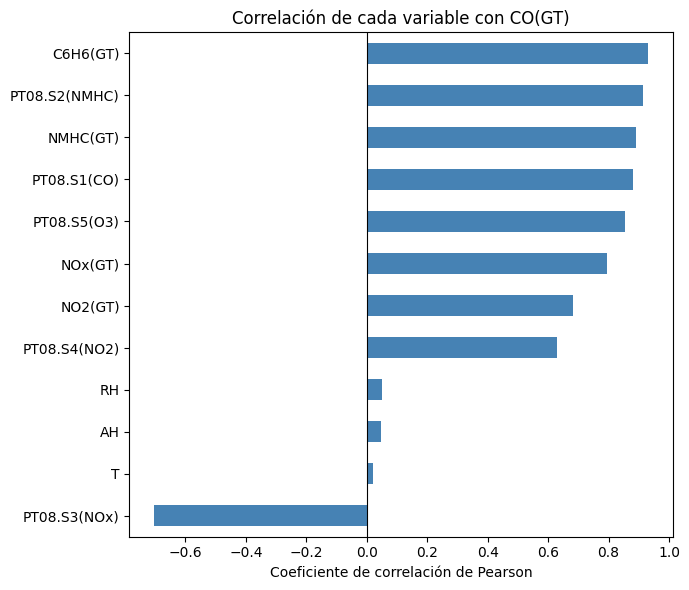

In [52]:
corr[objetivo].drop(objetivo).sort_values().plot(kind='barh', figsize=(7,6), color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f"Correlación de cada variable con {objetivo}")
plt.xlabel("Coeficiente de correlación de Pearson")
plt.tight_layout()
plt.show()

In [54]:
## ¿existe alguna variable que no tenga correlación?
corr[objetivo].abs().sort_values().head(5)

,CO(GT)
T,0.022109
AH,0.048556
RH,0.048890
PT08.S4(NO2),0.630703
NO2(GT),0.683343


Siguiendo el enfoque o análisis realizado; **Sí**: las variables meteorológicas **`T`** (r=0.02), **`RH`** (r=0.05) y **`AH`** (r=0.05) prácticamente no muestran correlación lineal con `CO(GT)`, vale tener en cuenta que no significa que la temperatura o la humedad no influyan en absoluto en la dispersión de contaminantes, sino que su relación con el CO, en caso de estar presente; no es lineal, y el coeficiente de Pearson no la detecta.

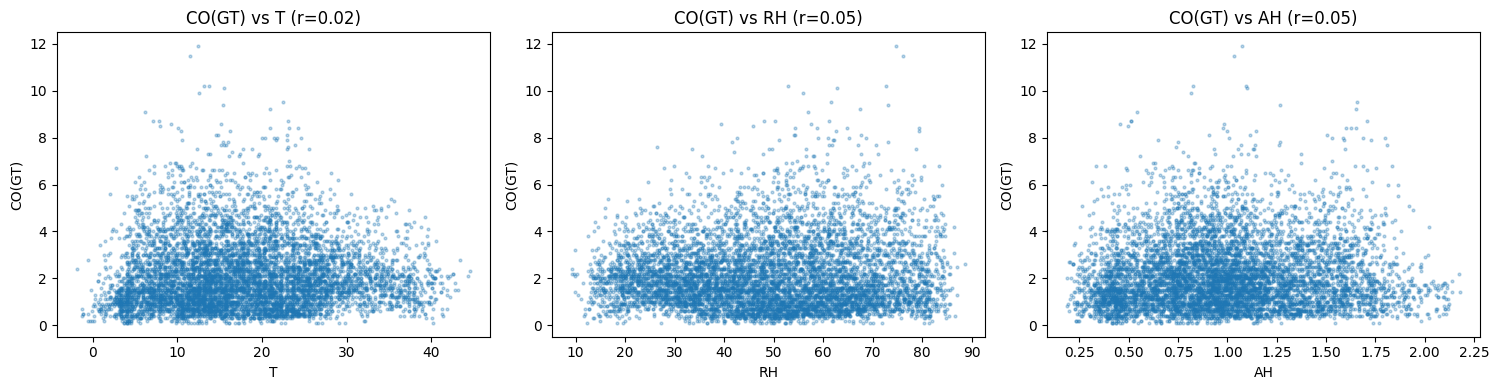

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['T', 'RH', 'AH']):
    ax.scatter(df_clean[col], df_clean[objetivo], s=4, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel(objetivo)
    ax.set_title(f"{objetivo} vs {col} (r={corr.loc[objetivo, col]:.2f})")
plt.tight_layout()
plt.show()

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

Del análisis exploratorio de datos realizado se llega a conclusiones relevantes para el modelado: (1) existe una fuerte **multicolinealidad**; es decir, cuando dos o más vaiables tienen una fuerte relación; en este caso, entre los contaminantes/sensores relacionados con la combustión, lo que hay que tener en cuenta al interpretar los coeficientes de un modelo lineal múltiple, puede afectar a la capacidad de interpretación, no tanto a la capacidad predictiva; (2) los valores perdidos están codificados como -200 y deberían tratarse como `NaN`, nunca como mediciones válidas; (3) `NMHC(GT)` debe excluirse como predictor debido a que su 90% de valores faltantes reduciría en gran medida el tamaño de la muestra útil; (4) la variable objetivo y varios predictores son asimétricos respecto de la alta contaminación, por lo que conviene escalar los datos y usar métricas de error robustas; (5) dado que algunas variables muestran una fuerte correlación lineal (r>0.85) con `CO(GT)`, es razonable que un modelo de regresión lineal múltiple obtenga buenos resultados como línea base, mientras que un árbol de decisión podría aportar valor si existen relaciones no lineales o interacciones entre variables. Todo esto bajo recomendaciones y tutelaje de compañeros docentes **estadísticos**.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [60]:
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

scaler = StandardScaler()

In [ ]:
# separar datos de entrenamiento y test

In [62]:
from sklearn.model_selection import train_test_split

feats = ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
         'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
# Se excluye NMHC(GT) del conjunto de predictores: con un 90.2% de valores faltantes,
# obligaría a descartar la inmensa mayoría de las filas (ver EDA / conclusiones).

data = df_clean[[objetivo] + feats].dropna().reset_index(drop=True)
print("Filas utilizables tras eliminar valores faltantes:", data.shape[0])

X = data[feats]
y = data[objetivo]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train.shape, " Test:", X_test.shape)

Filas utilizables tras eliminar valores faltantes: 6941
Train: (5552, 11)  Test: (1389, 11)


In [ ]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

In [66]:
# Con base en el EDA previo, se escogió PT08.S2 como variabe más correlacionada con CO(GT),
# pero PT08.S1(CO), es el sensor usado o diseñado para detectar CO; por tanto, para la
# regresión simpe es mucho más util.
simple_feat = 'PT08.S1(CO)'
X_train_simple = X_train[[simple_feat]]
X_test_simple = X_test[[simple_feat]]

In [67]:
# entrena el modelo con los datos de entrenamiento

In [68]:
from sklearn.linear_model import LinearRegression

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

LinearRegression()

In [ ]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

In [71]:
print("Coeficiente (pendiente):", lr_simple.coef_[0])
print("Intercepto:", lr_simple.intercept_)

Coeficiente (pendiente): 1.2773847335539523
Intercepto: 2.1819344380403454


Explica qué indican estos parámetros

El resultado de **intercepto** (≈2.18) indica el valor esperado de `CO(GT)` cuando la variable predictora `PT08.S1(CO)` toma su valor medio; es importante tener en cuenta que los datos están estandarizados, por lo que 0 representa la media muestral, no un sensor en reposo. El valor de **coeficiente** (≈1.28) indica que, por cada incremento de una desviación estándar en la lectura del sensor `PT08.S1(CO)`, el modelo predice o estima el aumento de aproximadamente 1.28 mg/m³ en la concentración estimada de CO. Ante esto, es necesario tener en cuentaa que ante datos escalados, el coeficiente se interpreta en desviaciones estándar, no en las unidades originales del sensor.

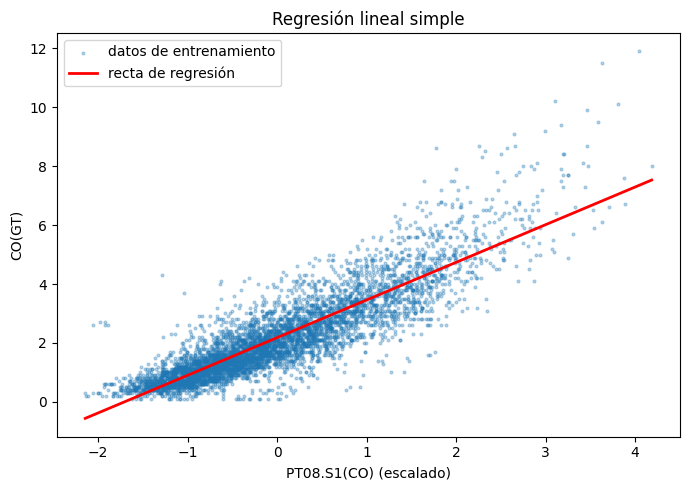

In [72]:
plt.figure(figsize=(7,5))
plt.scatter(X_train_simple, y_train, s=4, alpha=0.3, label="datos de entrenamiento")
x_line = np.linspace(X_train_simple.values.min(), X_train_simple.values.max(), 100).reshape(-1, 1)
plt.plot(x_line, lr_simple.predict(DataFrame(x_line, columns=[simple_feat])), color='red', linewidth=2, label="recta de regresión")
plt.xlabel(f"{simple_feat} (escalado)")
plt.ylabel(objetivo)
plt.legend()
plt.title("Regresión lineal simple")
plt.tight_layout()
plt.show()

In [ ]:
# realiza las predicciones para el conjunto de datos de test

In [73]:
y_pred_simple = lr_simple.predict(X_test_simple)

In [74]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)
print(f"MAE:  {mae_simple:.3f}")
print(f"RMSE: {rmse_simple:.3f}")
print(f"R2:   {r2_simple:.3f}")

MAE:  0.483
RMSE: 0.655
R2:   0.773


Vale tener en cuenta que `CO(GT)` tiene una distribución asimétrica con picos de contaminación legítimos o que tienen valores reales si cabe el término; conviene entonces,usar principalmente el **MAE** (error absoluto medio), que éste se expresa en las mismas unidades que la variable objetivo (mg/m³); todo esto, se complementa con el **R²** para valorar qué proporción de la varianza total explica el modelo, ya que en un contexto **"real"** como el caso de la _salud pública_ los errores grandes pueden ser más costosos en términos **de número de personas afectadas** que muchos errores pequeños.

In [75]:
# ¿Qué error tiene el modelo? Explícalo.
print(f"MAE = {mae_simple:.3f} mg/m3   |   RMSE = {rmse_simple:.3f} mg/m3   |   R2 = {r2_simple:.3f}")
print(f"Valor mínimo predicho: {y_pred_simple.min():.3f}   (mínimo real de CO(GT): {y.min()})")

MAE = 0.483 mg/m3   |   RMSE = 0.655 mg/m3   |   R2 = 0.773
Valor mínimo predicho: -0.442   (mínimo real de CO(GT): 0.1)


Un poco con ayuda de herramientas como **Claude**, revisión e interpretación de otros artículos [1](https://repositorio.puce.edu.ec/items/c45bd18f-b8b2-49ec-8a57-3b99c8220b5b/full), [2](https://airedemadrid.madrid.es/portales/calidadaire/es/Actuaciones-municipales/Sistema-integral-de-calidad-del-aire/Prediccion/Modelos-de-prediccion/?vgnextfmt=default&vgnextoid=fecefc8047df4710VgnVCM2000001f4a900aRCRD&vgnextchannel=4a7e471c5c503710VgnVCM1000008a4a900aRCRD), [3](https://www.sciencedirect.com/science/article/pii/S1110016824002485); el modelo simple obtiene **MAE=0.483 mg/m³, RMSE=0.655 mg/m³ y R²=0.773**; es decir, usando únicamente la lectura del sensor de CO se explica ya el 77% de la varianza de `CO(GT)`, y el error medio (0.48 mg/m³) es moderado si se compara con la media de la variable (2.15 mg/m³) y su desviación típica (1.45 mg/m³); todo esto supone aproximadamente un tercio de una desviación típica. Ante lo expuesto y luego de una interpretación bastante exhaustiva, asumo que como limitación relevante y atendiendo a un trabajo que realicé similiar en mi tesis doctoral, el modelo llega a predecir valores **negativos** (mínimo predicho ≈ -0.44 mg/m³); algo que se debe considerar como físicamente imposible para una concentración, lo cual es una limitación conocida de la regresión lineal sin restricciones cuando extrapola o se concluye fuera del rango de entrenamiento.

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [76]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

print("Intercepto:", lr_multi.intercept_)
print("\nCoeficientes:")
for feat, coefv in zip(X_train.columns, lr_multi.coef_):
    print(f"  {feat:15s}: {coefv: .4f}")

Intercepto: 2.181934438040345

Coeficientes:
  PT08.S1(CO)    :  0.2932
  C6H6(GT)       :  0.8775
  PT08.S2(NMHC)  : -0.0353
  NOx(GT)        :  0.3209
  PT08.S3(NOx)   :  0.0642
  NO2(GT)        :  0.1145
  PT08.S4(NO2)   :  0.2002
  PT08.S5(O3)    : -0.1406
  T              : -0.1849
  RH             : -0.0764
  AH             :  0.0037


In [77]:
y_pred_multi = lr_multi.predict(X_test)

In [78]:
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)
print(f"MAE:  {mae_multi:.3f}")
print(f"RMSE: {rmse_multi:.3f}")
print(f"R2:   {r2_multi:.3f}")

MAE:  0.258
RMSE: 0.398
R2:   0.916


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

Para este efecto; y de nuevo con ayuda de **Claude** y continuando la revisión con base en otros artículos que previamente he incorporado, el modelo múltiple obtiene **MAE=0.258 mg/m³, RMSE=0.398 mg/m³ y R²=0.916**, claramente **mejor** que el modelo simple (MAE=0.483, RMSE=0.655, R²=0.773): el error medio se reduce casi a la mitad y el modelo pasa de explicar el 77% al 92% de la varianza. Se asume que ahora tiene algo más de sentido al respecto, ya que ahora dispone de varias variables muy correlacionadas con el objetivo (`C6H6(GT)`, `PT08.S2(NMHC)`, `NOx(GT)`, etc.) en lugar de una sola. Para cerrar y espero no estar demasiado equivocado; considero que, si se llegan a obtener valores negativos por ejemplo para `PT08.S2(NMHC)`, esos resultados no deben interpretarse de forma aislada ya que su valor depende de qué otras variables correlacionadas estén también en el modelo.

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

- **criterion**: función que mide la calidad de una partición (para regresión: `squared_error`, `friedman_mse`, `absolute_error` o `poisson`).
- **splitter**: estrategia para elegir el punto de corte en cada nodo (`best` busca la mejor partición posible; `random` elige la mejor entre un subconjunto aleatorio de particiones, lo que añade aleatoriedad y puede reducir el sobreajuste).
- **max_depth**: profundidad máxima del árbol; controla su complejidad y es uno de los principales mecanismos contra el sobreajuste.
- **min_samples_split**: número mínimo de muestras que debe tener un nodo para poder dividirse.
- **min_samples_leaf**: número mínimo de muestras que debe tener cada hoja resultante; evita hojas demasiado específicas o ruidosas.
- **max_features**: número (o proporción) de variables consideradas al buscar la mejor partición en cada nodo; introduce aleatoriedad adicional y reduce la varianza del modelo.


Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

`min_impurity_decrease` establece que un nodo solo se dividirá si esa división reduce la impureza del nodo en, al menos, ese valor. Es un mecanismo de **pre-poda**: evita realizar particiones que aportan una mejora insignificante, lo que ayuda a controlar el sobreajuste, simplifica el árbol resultante (más interpretable) y reduce el tiempo de entrenamiento.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [84]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(criterion='poisson', max_depth=10, min_samples_split=10, min_samples_leaf=2, max_features=None, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=10, min_samples_leaf=2,
                      min_samples_split=10, random_state=42)

In [86]:
y_pred_dt_test = dt.predict(X_test)
y_pred_dt_train = dt.predict(X_train)

Calcula MAE, R2 y RMSLE

In [87]:
from sklearn.metrics import root_mean_squared_log_error

mae_dt = mean_absolute_error(y_test, y_pred_dt_test)
r2_dt = r2_score(y_test, y_pred_dt_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt_test))
# RMSLE exige valores no negativos; el árbol con criterio poisson ya predice valores >= 0,
# pero se recorta por seguridad ante cualquier valor residual negativo.
y_pred_dt_test_clip = np.clip(y_pred_dt_test, 0, None)
rmsle_dt = root_mean_squared_log_error(y_test, y_pred_dt_test_clip)

print(f"MAE:   {mae_dt:.3f}")
print(f"R2:    {r2_dt:.3f}")
print(f"RMSLE: {rmsle_dt:.3f}")

MAE:   0.310
R2:    0.879
RMSLE: 0.145


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

In [88]:
mae_dt_train = mean_absolute_error(y_train, y_pred_dt_train)
r2_dt_train = r2_score(y_train, y_pred_dt_train)
y_pred_dt_train_clip = np.clip(y_pred_dt_train, 0, None)
rmsle_dt_train = root_mean_squared_log_error(y_train, y_pred_dt_train_clip)

print("Entrenamiento -> MAE: {:.3f}  R2: {:.3f}  RMSLE: {:.3f}".format(mae_dt_train, r2_dt_train, rmsle_dt_train))
print("Test           -> MAE: {:.3f}  R2: {:.3f}  RMSLE: {:.3f}".format(mae_dt, r2_dt, rmsle_dt))

Entrenamiento -> MAE: 0.198  R2: 0.958  RMSLE: 0.098
Test           -> MAE: 0.310  R2: 0.879  RMSLE: 0.145


De nuevo; con ayuda de **Calude** y la revisión de información de otras fuentes;  **Sí, existe cierto sobreajuste (overfitting).**, en gran medida el modelo obtiene R²=0.958 y MAE=0.198 en entrenamiento, frente a R²=0.879 y MAE=0.310 en test: el rendimiento cae notablemente al pasar a datos no vistos, que es la señal característica del sobreajuste. Es entendible entonces; y dado que se ha permitido una profundidad considerable (`max_depth=10`) y hojas muy pequeñas (`min_samples_leaf=2`), lo que deja que el árbol memorice patrones muy específicos del conjunto de entrenamiento. Para comprobar/diagnosticar el sobreajuste en general se debe: (1) comparar sistemáticamente las métricas de train y test (una brecha grande indica sobreajuste, como aquí); (2) usar validación cruzada (k-fold) para obtener una estimación más robusta del rendimiento, en vez de depender de una única partición train/test; (3) generar curvas de validación (métrica frente a `max_depth`, `min_samples_leaf`, etc.) para localizar el punto en el que el error de test deja de mejorar mientras el de entrenamiento sigue bajando; y (4) inspeccionar la complejidad resultante del árbol (profundidad real alcanzada, número de hojas) en relación con el tamaño del dataset. Al final de este análisis debo reconocer que con la guía de **Claude** y el análisis de otros documentos, en cierta medida he podido extender la respuesta, teniendo en cuenta que mi análisis no es del todo estadístico, ya que vengo específicamente del área técnica.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

En esta sección, reconozco que haber hecho varios estudios con trabajos de pregrado, el mío a nivel doctoral y desde luego usando **Claude** he tenido una idea algo más clara; a todo esto, comparando los tres modelos por R² (test): regresión lineal simple = 0.773, árbol de decisión = 0.879, regresión lineal múltiple = 0.916. El árbol de decisión es **mejor que la regresión lineal simple** (usa 11 variables en vez de 1, y puede capturar relaciones no lineales, como la del sensor `PT08.S3(NOx)`), pero es **peor que la regresión lineal múltiple** en este caso concreto, principalmente porque el árbol sufre el sobreajuste descrito en la pregunta anterior: parte de su capacidad se enfoque o basa su esfuerzo en memorizar el ruido del entrenamiento en lugar de en generalizar; y esto, dado que la relación entre los predictores y `CO(GT)` es, en su mayoría, fuertemente lineal (varios r>0.85), un modelo lineal bien especificado y con pocos parámetros compite en ventaja frente a un árbol sin ajustar/podar cuidadosamente. Lo ideal podría ser y quizá esté equivocado, en que los modelos podrían no solo competir, sino tal vez trabajar en conjunto; pero este enfoque insisto es solo desde mi percepción como ingeniero informático.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

In [89]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión lineal simple', 'Regresión lineal múltiple', 'Árbol de decisión (poisson)'],
    'MAE':  [mae_simple, mae_multi, mae_dt],
    'RMSE': [rmse_simple, rmse_multi, rmse_dt],
    'R2':   [r2_simple, r2_multi, r2_dt],
})
resultados

,Modelo,MAE,RMSE,R2
0,Regresión lineal simple,0.483161,0.654879,0.772858
1,Regresión lineal múltiple,0.258386,0.397771,0.916201
2,Árbol de decisión (poisson),0.310434,0.478619,0.878674


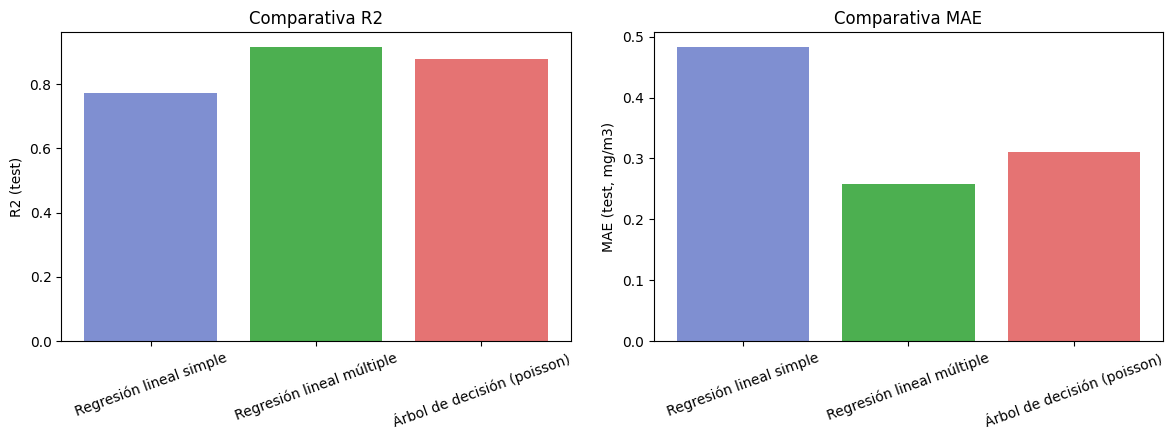

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colores = ['#7f8fd1', '#4caf50', '#e57373']

axes[0].bar(resultados['Modelo'], resultados['R2'], color=colores)
axes[0].set_ylabel('R2 (test)')
axes[0].set_title('Comparativa R2')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(resultados['Modelo'], resultados['MAE'], color=colores)
axes[1].set_ylabel('MAE (test, mg/m3)')
axes[1].set_title('Comparativa MAE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

En este experimento (con `random_state=42` y esta partición train/test concreta), el mejor modelo es la **regresión lineal múltiple**, con el R² más alto (0.916) y el MAE y RMSE más bajos, por delante del árbol de decisión (R²=0.879) y muy por delante de la regresión simple (R²=0.773). Esto es coherente con el EDA: varios predictores muestran relaciones fuertemente lineales con `CO(GT)` (r>0.85), por lo que un modelo lineal bien especificado, con pocos parámetros y poca varianza, ya captura casi toda la señal disponible. El árbol, pese a ser más flexible, sufre cierto sobreajuste que le impide superar al modelo lineal múltiple en este caso, aunque sigue superando claramente al modelo lineal de una sola variable. En cuanto a coste computacional, la regresión lineal múltiple es además el modelo más barato de entrenar y desplegar, un factor relevante en un equipo con recursos limitados. Como posible mejora futura, técnicas de *ensemble* sobre árboles (Random Forest, Gradient Boosting) o un ajuste de hiperparámetros del árbol (p. ej. reducir `max_depth` o aumentar `min_samples_leaf` para mitigar el sobreajuste observado) podrían cerrar o incluso revertir esta diferencia, pero exceden el alcance de esta actividad.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

**Referencia (APA, 7.ª ed.)**

Jumin, E., Zaini, N., Ahmed, A. N., Abdullah, S., Ismail, M., Sherif, M., Sefelnasr, A., & El-Shafie, A. (2020). Machine learning versus linear regression modelling approach for accurate ozone concentrations prediction. *Engineering Applications of Computational Fluid Mechanics*, 14(1), 713–725. https://doi.org/10.1080/19942060.2020.1758792


> Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.

**Objetivo de la investigación**

El estudio aborda la predicción de la concentración de ozono troposférico (O₃) en zonas urbanas de Kuala Lumpur y Selangor (Malasia), donde se documentan de forma recurrente niveles de ozono por encima de los límites permitidos. Los autores utilizan tres años de datos históricos de contaminantes y variables meteorológicas de tres estaciones de medición para construir modelos capaces de predecir la concentración de ozono con 24 y 12 horas de antelación, con el fin de disponer de un sistema de alerta temprana de calidad del aire. Es, por tanto, un problema de regresión sobre un caso real de contaminación atmosférica, muy próximo al que se ha trabajado en esta misma actividad.

**Técnicas de regresión empleadas y adaptación del algoritmo**

Comparan tres enfoques: regresión lineal, una red neuronal superficial (con dos variantes de normalización de entrada) y un árbol de decisión potenciado (*Boosted Decision Tree Regression*, BDTR); ninguno de ellos es una arquitectura de deep learning. Antes de entrenar, seleccionan las variables de entrada mediante el coeficiente de correlación de Pearson, de forma análoga al análisis de correlaciones realizado en esta actividad. La técnica de árbol de decisión no se usa en su forma más básica (un único árbol, como el `DecisionTreeRegressor` de esta actividad), sino en una versión **adaptada mediante boosting**: se entrena una secuencia de árboles poco profundos en la que cada nuevo árbol se centra en corregir los errores que ha dejado el árbol anterior, combinando finalmente sus predicciones. Esa es la adaptación del algoritmo de árboles de decisión que emplea el artículo. Adicionalmente, cuantifican la incertidumbre del modelo ganador mediante el intervalo de predicción al 95% (95PPU) y el factor-d, una técnica de cuantificación de incertidumbre poco habitual en trabajos de machine learning "puro" pero común en modelado ambiental.

**Principales resultados**

El árbol de decisión potenciado superó tanto a la regresión lineal como a la red neuronal en las tres estaciones evaluadas. Además, las predicciones a 12 horas resultaron más precisas que las de 24 horas, alcanzando valores de R² de 0.91, 0.88 y 0.87 en las tres estaciones. Entre las variables con mayor influencia sobre la formación de ozono se identificaron la velocidad del viento, la humedad y las concentraciones de óxidos de nitrógeno, monóxido de carbono y dióxido de nitrógeno, lo que coincide con el hallazgo de esta misma actividad de que los óxidos de nitrógeno y el monóxido de carbono están fuertemente correlacionados dentro de un mismo entorno de calidad del aire. El análisis de incertidumbre mostró una fiabilidad alta del modelo seleccionado (95PPU entre 93% y 97%, factor-d muy próximo a 0), reforzando la conclusión de que el árbol de decisión potenciado es el modelo más adecuado para este problema concreto.


## Declaración de uso de IA generativa

Este trabajo se ha completado con el apoyo de un asistente de IA generativa (Claude, de Anthropic), utilizado para: (1) redactar y depurar el código Python de carga, limpieza, análisis exploratorio y modelado de los datos; (2) generar las visualizaciones de apoyo (mapa de calor de correlaciones, gráficos comparativos); (3) redactar una primera versión de las respuestas a partir de los resultados numéricos obtenidos al ejecutar el código sobre `AirQualityUCI.csv`; y (4) una vez localizados los artículos científicos, usados y "enlazados" en el documento, ayudar a la interpretación y resumen de la información encontrada, tanto para el cuerpo del trabajo como del apartado de **Investigación**. Todas las cifras y métricas que aparecen en las respuestas proceden de la ejecución real del código, no han sido inventadas y las búsquedas y revisiones también fueron realizadas personalmente y son de entera responsabilidad del autor y en el repositorio de GitHub también se enccuentran los artículos empleados.

Gabriel Morejón López

[Repositorio en GitHub](https://github.com/elgabo82/Air_Quality_TAA-UNIR-A1.git)

[ORCID](https://orcid.org/0000-0001-8902-4583)


**Referencia de la IA (APA, 7.ª ed.)**

Anthropic. (2026). Claude (Version 5 Sonnet), (Versión 4.8 Opus) [Sonnet, Opus]. https://claude.ai/share/3ffe1955-573a-4e31-8079-09829b667cf3